Imports

In [59]:
import gymnasium as gym
from stable_baselines3 import A2C,PPO,SAC, TD3, DDPG
import five_bar
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import mediapy as media
import pandas as pd
import sympy as sp
import mujoco as mj


Import RL agent

In [60]:
RL_model_name="sac_enA-9.40_diA-6.38_enB-6.95_diB-7.68"

In [61]:
def model_load(env,RL_model_name):
    
    algo_name=RL_model_name.split("_")[0]
        
    path=os.path.join(os.path.dirname(os.getcwd()),"RL","trained_agents",RL_model_name,"agent.zip")
    
    if algo_name.lower() == 'ddpg':
        model = DDPG.load(path, env=env)
    elif algo_name.lower() == 'ppo':
        model = PPO.load(path, env=env)
    elif algo_name.lower() == 'a2c':
        model = A2C.load(path, env=env)
    elif algo_name.lower() == 'sac':
        model = SAC.load(path, env=env)
    elif algo_name.lower() == 'td3':
        model = TD3.load(path, env=env)
    else:
        raise ValueError(f"Algorithm {algo_name} not recognized. Please choose 'ddpg', 'ppo', 'a2c', 'sac' or td3.")
    
    return model


In [62]:
RL_env = gym.make("five_bar-v0", 
                  render_mode="rgb_array", 
                  camera_name="free",
                  reset_robot_pos_every_episode =False,
                  specify_data_configuration='(-,+)',
                  max_episode_steps=50,
                  specify_data_y_lims=[0.1,5],
                  specify_data_x_lims=None)
RL_model=model_load(RL_env,RL_model_name)
vec_env = RL_model.get_env()


In [63]:
obs = vec_env.reset()

episode=0

RL_test_frames=[]

RL_data_log=[]


while episode < 50:
    
    data=vec_env.unwrapped.env_method("get_simulation_state")[0]
    
    RL_data_log.append({
        'time': data["time"],
        
        'series_id': episode,
        
        'angle_p1': data["qpos"][0],
        'angle_p2': data["qpos"][2],
        'angle_p3': data["qpos"][1],
        'angle_p4': data["qpos"][3],
        
        'speed_p1': data["qvel"][0],
        'speed_p2': data["qvel"][2],
        'torque1': data["ctrl"][0],
        'torque2': data["ctrl"][1],
        'target_xy': (data["qpos"][4],data["qpos"][5]),
        'goal_pose':data["goal"]
    })
    
    RL_test_frames.append(vec_env.render(mode='rgb_array'))
    
    action, _ = RL_model.predict(obs, deterministic=True)
    
    obs, reward, done, info = vec_env.step(action)
    
    if done:
        
        episode += 1

RL_result_df = pd.DataFrame(RL_data_log)
RL_result_df["time"] = RL_result_df["time"] - RL_result_df["time"].iloc[0]


In [64]:
media.show_video(RL_test_frames, fps=60)

This browser does not support the video tag.


In [65]:
def quintic_trajectory(T,theta_i, theta_f, speed_i=0, speed_f=0, acceleration_i=0, acceleration_f=0):
    """
    Returns the coefficients [a0, a1, a2, a3, a4, a5] of the quintic polynomial:
    θ(t) = a0 + a1*t + a2*t^2 + a3*t^3 + a4*t^4 + a5*t^5
    that interpolates position, velocity, and acceleration at t=0 and t=T.
    """
    a0 = theta_i
    a1 = speed_i
    a2 = acceleration_i / 2

    # Setup linear system for [a3, a4, a5]
    A = np.array([
        [T**3,    T**4,     T**5],
        [3*T**2,  4*T**3,   5*T**4],
        [6*T,     12*T**2,  20*T**3]
    ])
    B = np.array([
        theta_f - (a0 + a1*T + a2*T**2),
        speed_f - (a1 + 2*a2*T),
        acceleration_f - (2*a2)
    ])

    a3, a4, a5 = np.linalg.solve(A, B)

    return [a0, a1, a2, a3, a4, a5]

def evaluate_quintic(coeffs, t, T):
    """
    Evaluates θ(t), θ̇(t), and θ̈(t) for a quintic polynomial:
    θ(t) = a0 + a1*t + a2*t^2 + a3*t^3 + a4*t^4 + a5*t^5

    Args:
        coeffs (list): Coefficients [a0, a1, a2, a3, a4, a5] of the quintic polynomial.
        t (float): Time at which to evaluate.
        T (float): Total duration, used to clamp t between 0 and T.

    Returns:
        list: [θ(t), θ̇(t), θ̈(t)]
    """
    a0, a1, a2, a3, a4, a5 = coeffs
    
    t = max(0, min(t, T))  # Clamp t to [0, T]

    theta = a0 + a1*t + a2*t**2 + a3*t**3 + a4*t**4 + a5*t**5
    theta_dot = a1 + 2*a2*t + 3*a3*t**2 + 4*a4*t**3 + 5*a5*t**4
    theta_dotdot = 2*a2 + 6*a3*t + 12*a4*t**2 + 20*a5*t**3

    return [theta, theta_dot, theta_dotdot]


def shortest_angle_diff(target, current):
    return (target - current + np.pi) % (2 * np.pi) - np.pi

In [66]:
all_targets=RL_result_df["target_xy"].unique()

all_target_angles=[]

for target in all_targets:
    temp_pose=RL_result_df[RL_result_df["target_xy"]==target].iloc[0]["goal_pose"]
    all_target_angles.append([temp_pose["q3"],temp_pose["q12"]])

initial_conditions=RL_result_df.iloc[0]

print(initial_conditions)

time                                                       0.0
series_id                                                    0
angle_p1                                              2.356194
angle_p2                                             -2.356194
angle_p3                                             -1.357087
angle_p4                                              1.357087
speed_p1                                                   0.0
speed_p2                                                   0.0
torque1                                                    0.0
torque2                                                    0.0
target_xy             (0.01897038317678356, 0.202775483540784)
goal_pose    q1             -0.078242
q2              0.028...
Name: 0, dtype: object


27.206345206477234


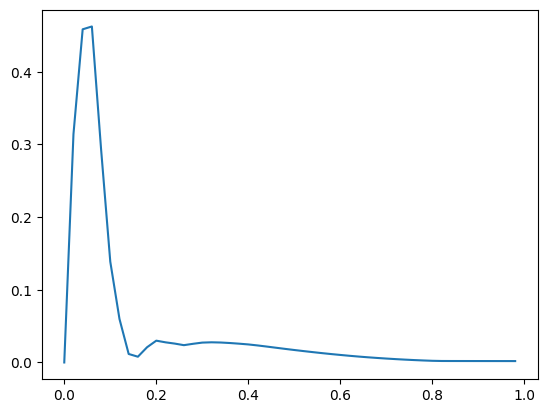

In [67]:
RL_result_df["power"] = (
    np.maximum(RL_result_df["torque1"] * RL_result_df["speed_p1"], 0) +
    np.maximum(RL_result_df["torque2"] * RL_result_df["speed_p2"], 0)
)
dt = RL_result_df["time"].diff().fillna(0)
RL_result_df["energy"] = RL_result_df["power"] * dt
total_energy = RL_result_df["energy"].sum()

print(total_energy)
plt.plot(RL_result_df["time"][:50], RL_result_df["power"][:50])

In [68]:
scene_option = mj.MjvOption()
cam = mj.MjvCamera()
cam.type = mj.mjtCamera.mjCAMERA_FREE
cam.fixedcamid = -1  # Free camera mode
cam.distance = 0.75   # Distance from lookat point
cam.azimuth = 90      # Rotation around vertical axis (0 for straight)
cam.elevation = -90  # -90 looks straight down
cam.lookat = np.array([0.0, 0.0, 0.0])


xml_path = os.path.join(os.path.dirname(os.getcwd()), "assets","5_bar.xml") #xml file (assumes this is in the same folder as this file)
model = mj.MjModel.from_xml_path(xml_path)  # MuJoCo model
data = mj.MjData(model) 

data.qpos[0] = initial_conditions["angle_p1"]
data.qpos[2] = initial_conditions["angle_p2"]

data.qpos[1] = initial_conditions["angle_p3"]
data.qpos[3] = initial_conditions["angle_p4"]

data.qvel[0] = 0
data.qvel[2] = 0

data.qvel[1] = 0
data.qvel[3] = 0

mj.mj_forward(model, data)
frames=[]

power_log = []
energy_log = []
dt = model.opt.timestep

total_time=model.opt.timestep*50*len(all_targets)

trajectory_time=0.3

t_0=data.time

actual_time=data.time-t_0

trajectory_time_offset=0

current_target_id=0

test_time=[]
test_data=[]

target_idx=0

current_angle_1=data.qpos[0]
current_angle_2=data.qpos[2]

target1=all_target_angles[target_idx][0]
target2=all_target_angles[target_idx][1]

adjusted_target1=current_angle_1+shortest_angle_diff(target1,current_angle_1)
adjusted_target2=current_angle_2+shortest_angle_diff(target2,current_angle_2)

coeffs_theta1=quintic_trajectory(trajectory_time,current_angle_1, adjusted_target1)
coeffs_theta2=quintic_trajectory(trajectory_time,current_angle_2, adjusted_target2)

print(np.rad2deg([current_angle_1,adjusted_target1]))
print(np.rad2deg([current_angle_2,adjusted_target2]))

with mj.Renderer(model) as renderer:
    while actual_time<total_time:
        
        objective_angle_1=evaluate_quintic(coeffs_theta1,actual_time-trajectory_time_offset,trajectory_time)[0]
        objective_angle_2=evaluate_quintic(coeffs_theta2,actual_time-trajectory_time_offset,trajectory_time)[0]
        
        objective_speed_1=evaluate_quintic(coeffs_theta1,actual_time-trajectory_time_offset,trajectory_time)[1]
        objective_speed_2=evaluate_quintic(coeffs_theta2,actual_time-trajectory_time_offset,trajectory_time)[1]


        
        data.ctrl[0] = 0.02*(180/np.pi)*(objective_angle_1 - data.qpos[0]) + 0.005*(180/np.pi)*(objective_speed_1 - data.qvel[0])
        data.ctrl[1] = 0.02*(180/np.pi)*(objective_angle_2 - data.qpos[2]) + 0.005*(180/np.pi)*(objective_speed_2 - data.qvel[2])
        
        test_data.append(data.qpos[0])
        test_time.append(data.time)
        
        torques=np.array([data.ctrl[0],data.ctrl[1]])
        speeds  = np.array([data.qvel[0], data.qvel[2]])
        
        power = np.sum(np.maximum(torques * speeds, 0))
        power_log.append(power)
        energy_log.append(power * dt)
        mj.mj_step(model, data)
        actual_time=data.time-t_0

        renderer.update_scene(data, scene_option=scene_option, camera=cam)
        pixels = renderer.render()
        frames.append(pixels)
        
        if actual_time-trajectory_time_offset>0.5:
            target_idx+=1
            trajectory_time_offset=actual_time
            current_angle_1=data.qpos[0]
            current_angle_2=data.qpos[2]

            target1=all_target_angles[target_idx][0]
            target2=all_target_angles[target_idx][1]

            adjusted_target1=current_angle_1+shortest_angle_diff(target1,current_angle_1)
            adjusted_target2=current_angle_2+shortest_angle_diff(target2,current_angle_2)

            coeffs_theta1=quintic_trajectory(trajectory_time,current_angle_1, adjusted_target1)
            coeffs_theta2=quintic_trajectory(trajectory_time,current_angle_2, adjusted_target2)
        
    
media.show_video(frames, fps=60)

[135.         144.57089805]
[-135.        -158.4328496]


This browser does not support the video tag.


Total mechanical energy: 30.9699 J


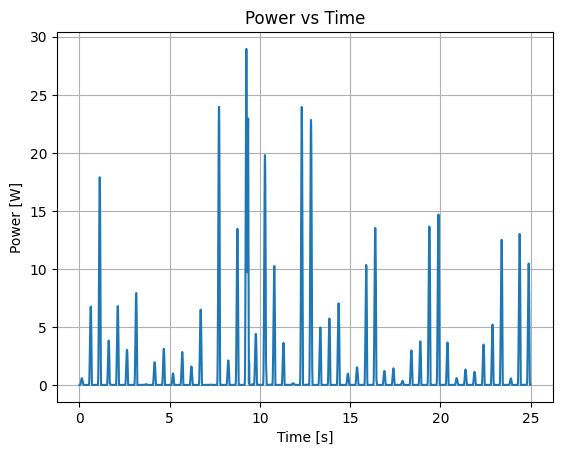

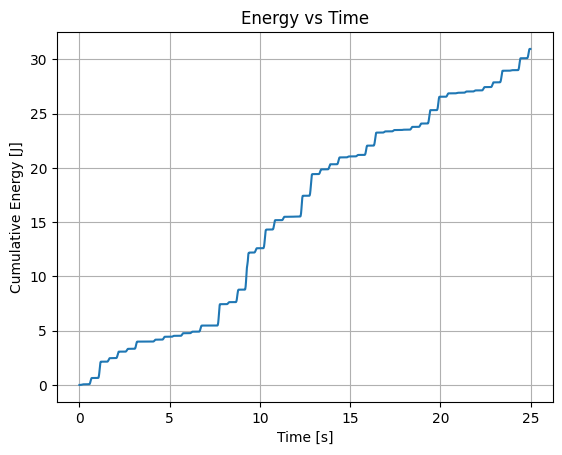

In [69]:
test_time = np.array(test_time)

# Convert to numpy arrays
power_log = np.array(power_log)
energy_log = np.array(energy_log)
cumulative_energy = np.cumsum(energy_log)

print(f"Total mechanical energy: {cumulative_energy[-1]:.4f} J")

# Plot power
plt.figure()
plt.plot(test_time, power_log)
plt.xlabel("Time [s]")
plt.ylabel("Power [W]")
plt.title("Power vs Time")
plt.grid(True)

# Plot cumulative energy
plt.figure()
plt.plot(test_time, cumulative_energy)
plt.xlabel("Time [s]")
plt.ylabel("Cumulative Energy [J]")
plt.title("Energy vs Time")
plt.grid(True)
plt.show()


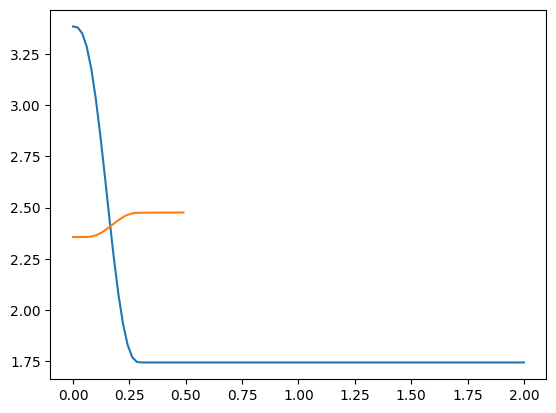

In [70]:
times=np.linspace(0,2,100)

plt.plot(times,[evaluate_quintic(coeffs_theta1,time,trajectory_time)[0] for time in times])
plt.plot(test_time[:50],test_data[:50])

In [71]:
# Parameters
scale = 0.5

# Motor coordinates
O_1x, O_2x,O_1y, O_2y = -0.075 * scale, 0.075 * scale,0 * scale, 0 * scale

# Link lengths
L_p1, L_p2, L_d1, L_d2 = [0.2 * scale, 0.2 * scale, 0.4 * scale, 0.4 * scale]

# A known configuration for the mechanism
q_base=np.vstack([-0.14571*scale,0.07071*scale,np.deg2rad(135),
     -0.10821*scale,0.30962*scale,np.deg2rad(57.244623466),
     0.10821*scale,0.30962*scale,np.deg2rad(-57.244623466),
     0.14571*scale,0.07071*scale,np.deg2rad(-135)])

# Symbolic variables
t = sp.Symbol('t')

phi_p1, phi_p2, phi_d1, phi_d2 = sp.symbols('phi_p1 phi_p2 phi_d1 phi_d2')
x_p1, y_p1, x_p2, y_p2 = sp.symbols('x_p1 y_p1 x_p2 y_p2')
x_d1, y_d1, x_d2, y_d2 = sp.symbols('x_d1 y_d1 x_d2 y_d2')

val_effx, val_effy = sp.symbols('val_effx val_effy')

sym_phi_p1, sym_phi_p2 = sp.symbols('sym_phi_p1 sym_phi_p2')

# Rotation matrix function (symbolic and numeric)
def rotmat(phi):
    return sp.Matrix([[sp.cos(phi), -sp.sin(phi)], [sp.sin(phi), sp.cos(phi)]])

def rotmat_num(phi):
    return np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]])

# Generalized coordinates vector
q = sp.Matrix([x_p1, y_p1, phi_p1, x_d1, y_d1, phi_d1, x_d2, y_d2, phi_d2, x_p2, y_p2, phi_p2])

# Number of generalized coordinates
nq=len(q)

# Joint equations
# Proximal link 1 - Ground
eq1 = sp.Matrix([x_p1, y_p1]) + rotmat(phi_p1) * sp.Matrix([-L_p1 / 2, 0]) - sp.Matrix([O_1x, O_1y])

# Proximal link 1 - Distal Link 1
eq2 = sp.Matrix([x_p1, y_p1]) + rotmat(phi_p1) * sp.Matrix([L_p1 / 2, 0]) - (sp.Matrix([x_d1, y_d1]) + rotmat(phi_d1) * sp.Matrix([-L_d1 / 2, 0]))

#  Proximal link 1 - Distal Link 1
eq3 = sp.Matrix([x_d1, y_d1]) + rotmat(phi_d1) * sp.Matrix([L_d1 / 2, 0]) - (sp.Matrix([x_d2, y_d2]) + rotmat(phi_d2) * sp.Matrix([-L_d2 / 2, 0]))

# Distal Link 2 - Proximal Link 2
eq4 = sp.Matrix([x_d2, y_d2]) + rotmat(phi_d2) * sp.Matrix([L_d2 / 2, 0]) - (sp.Matrix([x_p2, y_p2]) + rotmat(phi_p2) * sp.Matrix([-L_p2 / 2, 0]))

# Proximal Link 2 - Ground
eq5 = sp.Matrix([x_p2, y_p2]) + rotmat(phi_p2) * sp.Matrix([L_p2 / 2, 0]) - sp.Matrix([O_2x, O_2y])

# Actuation Equations
eq6_direct = sp.Matrix([phi_p1, phi_p2]) - sp.Matrix([sym_phi_p1, sym_phi_p2])
eq6_inverse = sp.Matrix([val_effx, val_effy]) - sp.Matrix([x_d1, y_d1]) - rotmat(phi_d1) * sp.Matrix([L_d1 / 2, 0])

# Constraint vector
PHI_direct = sp.simplify(sp.Matrix.vstack(eq1, eq2, eq3, eq4, eq5, eq6_direct))
PHI_inverse = sp.simplify(sp.Matrix.vstack(eq1, eq2, eq3, eq4, eq5, eq6_inverse))

# Calculates Jacobian
PHI_q_direct = PHI_direct.jacobian(q)
PHI_q_inverse = PHI_inverse.jacobian(q)

# Convert symbolic expressions to numerical functions
PHI_fun_direct = sp.lambdify((q, sym_phi_p1,sym_phi_p2), PHI_direct, 'numpy')
PHI_fun_inverse = sp.lambdify((q, val_effx,val_effy), PHI_inverse, 'numpy')


PHI_q_fun_direct = sp.lambdify((q, sym_phi_p1,sym_phi_p2), PHI_q_direct, 'numpy')
PHI_q_fun_inverse = sp.lambdify((q, val_effx,val_effy), PHI_q_inverse, 'numpy')

In [72]:
def angles_from_xy(q_0,x_coord,y_coord):
    # Newton - Rhapson Solver Parameters
    tol=1e-6
    max_iters=100
 
    j=1 # Reset iteration counter
    q_ant=q_0 # Pick random solution from the ones solved
    q_0=np.vstack(q_ant) # Use random solution as the initial guess for the next iteration
    
    while True:

        phi_val=PHI_fun_inverse(q_0.flatten(),x_coord,y_coord)
        
        inv_phi_q_val=np.linalg.inv(PHI_q_fun_inverse(q_0.flatten(),x_coord,y_coord))
        
        q_1=q_0-inv_phi_q_val@phi_val
        
        if j>max_iters:
            return None
        
        if max(abs(phi_val))<=tol:
            
            q_sol=q_0
            theta1=q_sol.flatten()[2]
            theta2=q_sol.flatten()[11]
            theta3=q_sol.flatten()[5]-q_sol.flatten()[2]
            theta4=q_sol.flatten()[8]-q_sol.flatten()[11]
        

            return q_sol.flatten()
        q_0=q_1
        j+=1

In [73]:
q_act=angles_from_xy(q_base,0.2,-0.)
print(q_act)

[-9.70394737e-03 -4.15617548e-02  5.30185959e+00  1.09046053e-01
 -4.15617548e-02  4.28621665e-01  1.13221192e-01  4.96934812e-02
 -3.66165556e+00  3.19711925e-02  4.96934812e-02  1.73895621e+01]


In [74]:
q_act=angles_from_xy(q_act,0.2,-0.1)
print(q_act)

[-1.86824065e-02 -4.63238411e-02  5.09824447e+00  1.00067593e-01
 -9.63238411e-02 -3.67698745e-02  1.51731585e-01 -1.24205496e-02
 -4.20867203e+00  7.04815852e-02  3.75794504e-02  1.65584310e+01]


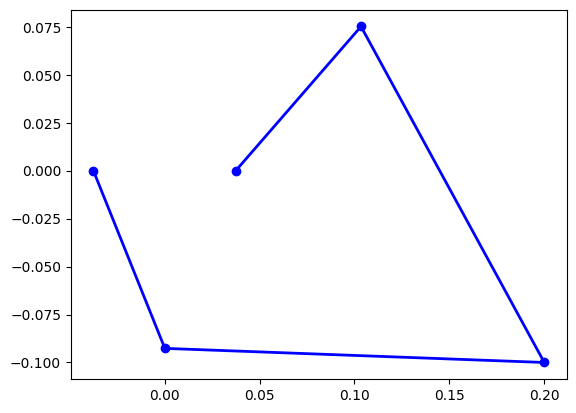

In [75]:
pts=np.column_stack([
        [q_act[0], q_act[1]] + rotmat_num(q_act[2]) @ np.array([-L_p1/ 2, 0]),
        [q_act[0], q_act[1]] + rotmat_num(q_act[2]) @ np.array([L_p1 / 2, 0]),
        [q_act[3], q_act[4]] + rotmat_num(q_act[5]) @ np.array([L_d1 / 2, 0]),
        [q_act[9], q_act[10]] + rotmat_num(q_act[11]) @ np.array([-L_p2 / 2, 0]),
        [q_act[9], q_act[10]] + rotmat_num(q_act[11]) @ np.array([L_p2 / 2, 0])
    ])

plt.plot(pts[0, :], pts[1, :], 'bo-', lw=2)